<a href="https://colab.research.google.com/github/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/blob/main/CIND_820_Notebook_4_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Libraries**

In [ ]:
#Check the version of Python being run
!python --version

# Install all dependencies
!pip install pandas matplotlib seaborn ipython numpy vaderSentiment xgboost shap

#Import Libraries
#Data Manipulation, Cleaning, and Analysis
import pandas as pd
import numpy as np
from scipy.stats import skew, shapiro

#Formatting and Visualizations
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from IPython.display import FileLink
from IPython.display import IFrame

#Natural Language Processing (NLP)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

#Modelling and Performance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap

#Timer for models
import time

Python 3.12.13


# **2. Download Listings & Reviews Data from Insideairbnb.com**

In [ ]:
#LISTINGS
#Import files
url_toronto = "https://data.insideairbnb.com/canada/on/toronto/2025-11-11/data/listings.csv.gz"
df_toronto = pd.read_csv(url_toronto, compression='gzip')

url_montreal = "https://data.insideairbnb.com/canada/qc/montreal/2025-09-18/data/listings.csv.gz"
df_montreal = pd.read_csv(url_montreal, compression='gzip')

url_ottawa = "https://data.insideairbnb.com/canada/on/ottawa/2025-09-22/data/listings.csv.gz"
df_ottawa = pd.read_csv(url_ottawa, compression='gzip')

#Add city labels
df_toronto['city'] = 'Toronto'
df_montreal['city'] = 'Montreal'
df_ottawa['city'] = 'Ottawa'

#Combine data
df_listings = pd.concat([df_toronto, df_montreal, df_ottawa], ignore_index=True)

#Encode city labels for future modelling
df_listings['city_code'] = df_listings['city'].map({
    'Toronto': 1,
    'Montreal': 2,
    'Ottawa': 3})

#Rename ID to listings_ID to match reviews dataset
df_listings.rename(columns={"id": "listing_id"}, inplace=True)

#REVIEWS
#Import files
url_toronto = "https://data.insideairbnb.com/canada/on/toronto/2025-11-11/data/reviews.csv.gz"
df_toronto_reviews = pd.read_csv(url_toronto, compression='gzip')

url_montreal = "https://data.insideairbnb.com/canada/qc/montreal/2025-09-18/data/reviews.csv.gz"
df_montreal_reviews = pd.read_csv(url_montreal, compression='gzip')

url_ottawa = "https://data.insideairbnb.com/canada/on/ottawa/2025-09-22/data/reviews.csv.gz"
df_ottawa_reviews = pd.read_csv(url_ottawa, compression='gzip')

#Add city labels
df_toronto_reviews['city'] = 'Toronto'
df_montreal_reviews['city'] = 'Montreal'
df_ottawa_reviews['city'] = 'Ottawa'

#Combine data
df_reviews = pd.concat([df_toronto_reviews, df_montreal_reviews, df_ottawa_reviews], ignore_index=True)

#Encode city labels for future modelling
df_reviews['city_code'] = df_reviews['city'].map({
    'Toronto': 1,
    'Montreal': 2,
    'Ottawa': 3})


# **3. Dataset Overview**

In [ ]:
#Summarize Listings Data
print(f"""
DATASET OVERVIEW
----------------
Rows: {df_listings.shape[0]:,}
Columns: {df_listings.shape[1]}

FIRST 5 ROWS
---------------""")
display(df_listings.head())

#Summarize Reviews Data
print(f"""
DATASET OVERVIEW
----------------
Rows: {df_reviews.shape[0]:,}
Columns: {df_reviews.shape[1]}

FIRST 5 ROWS
---------------""")
display(df_reviews.head())


DATASET OVERVIEW
----------------
Rows: 33,748
Columns: 81

FIRST 5 ROWS
---------------


,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,city_code
0,1419,https://www.airbnb.com/rooms/1419,20251111064035,2025-11-11,previous scrape,Beautiful home in amazing area!,"This large, family home is located in one of T...",The apartment is located in the Ossington stri...,https://a0.muscache.com/pictures/76206750/d643...,1565,...,5.00,NaN,f,1,1,0,0,0.05,Toronto,1
1,8077,https://www.airbnb.com/rooms/8077,20251111064035,2025-11-11,previous scrape,Downtown Harbourfront Private Room,Guest room in a luxury condo with access to al...,NaN,https://a0.muscache.com/pictures/11780344/141c...,22795,...,4.83,NaN,f,2,1,1,0,0.85,Toronto,1
2,26654,https://www.airbnb.com/rooms/26654,20251111064035,2025-11-11,city scrape,"World Class @ CN Tower, convention centre, The...","CN Tower, TIFF Bell Lightbox, Metro Convention...",There's a reason they call it the Entertainmen...,https://a0.muscache.com/pictures/81811785/5dcd...,113345,...,4.69,NaN,f,3,3,0,0,0.25,Toronto,1
3,27423,https://www.airbnb.com/rooms/27423,20251111064035,2025-11-12,city scrape,Executive Studio Unit- Ideal for One Person,"Brand new, fully furnished studio basement apa...",NaN,https://a0.muscache.com/pictures/176936/b687ed...,118124,...,4.88,NaN,f,1,1,0,0,0.16,Toronto,1
4,30931,https://www.airbnb.com/rooms/30931,20251111064035,2025-11-11,previous scrape,Downtown Toronto - Waterview Condo,Split level waterfront condo with a breathtaki...,NaN,https://a0.muscache.com/pictures/227971/e8ebd7...,22795,...,NaN,NaN,f,2,1,1,0,0.01,Toronto,1



DATASET OVERVIEW
----------------
Rows: 1,195,735
Columns: 8

FIRST 5 ROWS
---------------


,listing_id,id,date,reviewer_id,reviewer_name,comments,city,city_code
0,9974111,105972997,2016-10-03,74630712,Lily,I absolutely loved the location!! I was there ...,Toronto,1
1,9974111,125205050,2017-01-04,23609,Mark,"Stayed here for 2 weeks , great location , gre...",Toronto,1
2,9974111,191232367,2017-09-06,147270253,Dianne,Awesome location! Communication with Shoug was...,Toronto,1
3,9974111,196001139,2017-09-21,5590969,Charie,Had a really great two week stay at Shoug's pl...,Toronto,1
4,9974111,197975881,2017-09-27,76030814,Oswald,great and easy stay - no issues at all,Toronto,1


# **4. Preprocess Datasets According to Findings from Exploratory Data Analysis (EDA)**
  For further analysis, please see the files stored in this directory:
  [Exploratory Data Analysis (EDA)](https://github.com/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/tree/main/Exploratory%20Data%20Analysis%20(EDA))
  
  [Notebook 1 - Automated Exploratory Data Analysis](https://github.com/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/blob/main/Exploratory%20Data%20Analysis%20(EDA)/Notebook%201%20-%20Automated%20Exploratory%20Data%20Analysis%20-%20Data%20Types%2C%20Distributions%2C%20Skewness%2C%20and%20Correlations.ipynb)

  [Notebook 2 - Manual Exploratory Data Analysis](https://github.com/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/blob/main/Exploratory%20Data%20Analysis%20(EDA)/Notebook%202%20-%20Manual%20Exploratory%20Data%20Analysis.ipynb)
  
  [Notebook 3 - Manual Exploratory Data Analysis of Reviews.ipynb](https://github.com/AgacheM/Analyzing-Toronto-Montreal-and-Ottawa-Airbnb-Datasets/blob/main/Exploratory%20Data%20Analysis%20(EDA)/Notebook%203%20-%20Manual%20Exploratory%20Data%20Analysis%20of%20Reviews.ipynb)



# **5. Identify and Handle Missing Values**

In [ ]:
#LISTINGS DATA
#Drop features with >50% Missing values
print ("Missing Values:")
missing = df_listings.isnull().sum()
missing = missing[missing>0]

missing_percent=(missing/len(df_listings))*100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

#View only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"]>0]

print ("Drop features with >50% missing values")

columns_to_drop = missing_summary[missing_summary["Missing %"]>50].index
df_listings = df_listings.drop(columns=columns_to_drop)

print(f"""Dropped {len(columns_to_drop)} columns with high missing values.""")
print(f"""Dropped columns: {(columns_to_drop)}""")

#REVIEWS DATA
#Drop rows with no comments
df_reviews = df_reviews.dropna(subset=["comments"])

Missing Values:
Drop features with >50% missing values
Dropped 6 columns with high missing values.
Dropped columns: Index(['neighborhood_overview', 'host_about', 'host_neighbourhood',
       'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated'],
      dtype='object')


# **6. Manual Feature Selection: Drop Columns Containing Personally Identifiable Information (PII) or not Adding Analytical Value**

In [ ]:
#LISTINGS DATA
#The columns below will be dropped, due to  PII concerns, low variablity, or in the case of metadata, due to a lack of signifiant value in determining price
more_columns_to_drop = [
    #IDs
    'host_id', 'scrape_id',
    #URLs or Images
    'listing_url', 'host_url', 'picture_url', 'host_thumbnail_url', 'host_picture_url',
    #Text Fields
    'name', 'description', 'neighborhood_overview','host_about', 'amenities',
    #Host Info or PII
    'host_name', 'host_location', 'host_neighbourhood','host_verifications',
    #Metadata
    'last_scraped', 'calendar_last_scraped','calendar_updated', 'source',
    #Redundant Counts to host_listing_counts
    'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms',
    #Redundant to Availability, Estimated Occupancy
    "estimated_occupancy_l365d",
    #Redundant column to City Code, City
    'city',
    #Low Analytical Value due to Low Variability
    'host_has_profile_pic', 'host_identity_verified']

df_listings = df_listings.drop(columns=more_columns_to_drop, errors='ignore')

print (f"""Dropped {len(more_columns_to_drop)} columns representing PII or not adding analytical value in the listings data.""")

#REVIEWS DATA
more_columns_to_drop = [
#Reviewer Info or PII
'reviewer_name',
#Metadata
'date','reviewer_id']

df_reviews = df_reviews.drop(columns=more_columns_to_drop, errors='ignore')

print (f"""Dropped {len(more_columns_to_drop)} columns representing PII or not adding analytical value in the reviews data.""")

Dropped 27 columns representing PII or not adding analytical value in the listings data.
Dropped 3 columns representing PII or not adding analytical value in the reviews data.


# **7. Data Cleaning: Missing Values in Columns and Data Types**

In [ ]:
#LISTINGS DATA
#NUMBER OF REVIEWS
#Handle missing values in reviews_per_month by imputing 0
df_listings['reviews_per_month'] = df_listings['reviews_per_month'].fillna(0)

#Transform number_of_reviews from string to integer
df_listings['reviews_per_month'] = df_listings['reviews_per_month'].astype(int)

#PRICE
#Transform Price from string to numerical, removing "$ and ," characters
df_listings['price'] = df_listings['price'].replace(r'[\$,]', '', regex=True).astype(float)

#Handle missing values in price by imputing median
median_price = df_listings['price'].median()
df_listings['price'] = df_listings['price'].fillna(median_price)

#DATES
#Transform dates from string to datetime
df_listings["host_since"] = pd.to_datetime(df_listings["host_since"], errors="coerce")
df_listings["first_review"] = pd.to_datetime(df_listings["first_review"], errors="coerce")
df_listings["last_review"] = pd.to_datetime(df_listings["last_review"], errors="coerce")

#Transform dates to length of years since current date
#Host Since
df_listings["host_year"] = df_listings["host_since"].dt.year
df_listings["years_as_host"] = (pd.Timestamp.today().year- df_listings["host_since"].dt.year)

# First review
df_listings["first_review_year"] = df_listings["first_review"].dt.year
df_listings["years_since_first_review"] = (pd.Timestamp.today().year-df_listings["first_review"].dt.year)

# Last review
df_listings["last_review_year"] = df_listings["last_review"].dt.year

df_listings["years_since_last_review"] = (pd.Timestamp.today().year-df_listings["last_review"].dt.year)

#Drop original datetime columns
df_listings.drop(columns=["host_since", "first_review","last_review"],inplace=True)

#PERCENTAGE RATES COLUMNS
#Transform host_response_rate, host_acceptance_rate from string % to numerical %
df_listings['host_response_rate'] = (df_listings['host_response_rate'].str.replace('%', '').astype(float) / 100)
df_listings['host_acceptance_rate'] = (df_listings['host_acceptance_rate'].str.replace('%', '').astype(float) / 100)

#Fill missing values in host_response & acceptance_rates with 0%, as the host has never replied
df_listings['host_response_rate'] = df_listings['host_response_rate'].fillna('0%')
df_listings['host_acceptance_rate'] = df_listings['host_acceptance_rate'].fillna('0%')

#BOOLEAN COLUMNS
#Fill missing values in host_is_superhost, has_availability & instant_bookable with False
df_listings['host_is_superhost'] = df_listings['host_is_superhost'].fillna('f')
df_listings['has_availability'] = df_listings['has_availability'].fillna('f')
df_listings['instant_bookable'] = df_listings['instant_bookable'].fillna('f')

#Now convert the True/False boolean columns to 1 or 0:
boolean_columns = ['host_is_superhost','has_availability','instant_bookable']
for col in boolean_columns:df_listings[col] = df_listings[col].map({'t': 1,'f': 0,})

#Check Result of Boolean columns
print(f"""Check Result of Boolean column transformation:
{df_listings['host_is_superhost'].unique()}
{df_listings['has_availability'].unique()}
{df_listings['instant_bookable'].unique()}
""" )

#Transform number of bathrooms from ordinal categorical to numeric (discrete)
#Create new numeric column from bathrooms_text
df_listings['bathrooms_text_to_numeric'] = (df_listings['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float))

#Check Result of Bathrooms
print(f"""Check unique values of transformation from bathroom text to numeric: {df_listings['bathrooms_text_to_numeric'].unique()}""")

Check Result of Boolean column transformation:
[0 1]
[1 0]
[0 1]

Check unique values of transformation from bathroom text to numeric: [ 3.   1.5  1.   nan  2.   4.   0.   2.5  5.   3.5  4.5  5.5  6.5  6.
 20.   7.   7.5  8.  16.  12.  10.   9. ]


# **8. Handle Skewness in Price using Log Transformation**

Skewness Value of Price = 36.39

Log transformation is applied to reduce skewness in price.

Check the log transformation:

0    4.820282
1    4.820282
2    4.897840
3    4.330733
4    4.820282
Name: log price, dtype: float64

Log-transformed skewness = 0.66


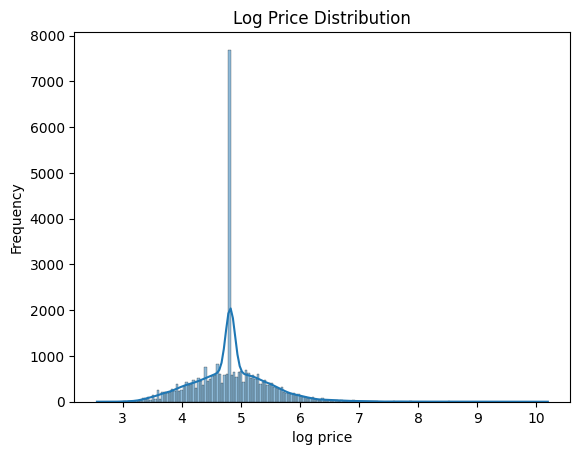

In [ ]:
#Check skewness
print(f"""Skewness Value of Price = {df_listings['price'].skew():.2f}

Log transformation is applied to reduce skewness in price.
""")

#Log transform and add to both listings datasets
df_listings['log price'] = np.log1p(df_listings['price'])


#Check results
print("Check the log transformation:\n")
print(df_listings['log price'].head())
print(f"\nLog-transformed skewness = {df_listings['log price'].skew():.2f}")

#Plot Result
sns.histplot(df_listings['log price'], kde=True)
plt.title("Log Price Distribution")
plt.ylabel("Frequency")
plt.show()

# **9. Feature Selection: Drop Redundant or Features with Low Explanatory Power**

In [ ]:
print(f"""Unique license values will be dropped as there are {df_listings['license'].nunique():,}, among total obseravations of {len(df_listings):,}, which shows high cardinality and low predictive power.""")

extra_cols_to_drop = [

    'beds', #Redundant to accommodates (# of people the property accommodates)
    'host_has_profile_pic', #Low value due to low variance
    'host_identity_verified', #Low value due to low variance

    #Redundant to log-price
    'estimated_revenue_l365d',
    'price',

    #Redundant to City
    'latitude',
    'longitude',

    #Redundant to overall review_scores_rating
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',

    #Redundant to Availability_365
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_eoy',

    #Redundant to host_listings_count
    'host_total_listings_count',
    'calculated_host_listings_count',

    #Redundant to minimum_nights or maximum_nights
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',

    #Redundant to reviews_per_month
    'number_of_reviews',
    'number_of_reviews_l30d',
    'number_of_reviews_ltm',
    'number_of_reviews_ly',

    #Redundant to bathrooms_text_to_numeric
    'bathrooms',
    'bathrooms_text',

    #Redundant to neighbourhood_cleansed
    'neighbourhood',
    'neighbourhood_group_cleansed',

    #High Cardinality,
    'license']


df_listings = df_listings.drop(columns=extra_cols_to_drop, errors='ignore')

print(f"""
We have dropped the following columns during feature selection, due to their redundancy, low variance, or low explanatory power:
{extra_cols_to_drop}""")

Unique license values will be dropped as there are 11,877, among total obseravations of 33,748, which shows high cardinality and low predictive power.

We have dropped the following columns during feature selection, due to their redundancy, low variance, or low explanatory power:
['beds', 'host_has_profile_pic', 'host_identity_verified', 'estimated_revenue_l365d', 'price', 'latitude', 'longitude', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'availability_30', 'availability_60', 'availability_90', 'availability_eoy', 'host_total_listings_count', 'calculated_host_listings_count', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'number_of_reviews', 'number_of_reviews_l30d', 'number_of_reviews_ltm', 'number_of_reviews_ly', 'bathrooms', 'bathrooms

# **10. Run Sentiment Analysis on Reviews Dataset and Output Sentiment Score per each Review**

In [ ]:
#Initialize sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

#Define function, outputting VADER compound sentiment score (-1 to +1)
def get_sentiment(text):
    return analyzer.polarity_scores(str(text))["compound"]

#Apply function and check results
df_reviews["sentiment_score_compound"] = df_reviews["comments"].apply(get_sentiment)
display(df_reviews[["comments", "sentiment_score_compound"]].tail())

,comments,sentiment_score_compound
1195730,"Very friendly, very clean & exactly what I was...",0.7930
1195731,As soon as I pulled up there was a bunch of ga...,0.9360
1195732,"Upon checking in, we noticed that the renovati...",-0.5996
1195733,We had an amazing stay at this place. Host was...,0.7430
1195734,"great location, close to airport and highway. ...",0.8016


# **11. Aggregate Multiple Sentiment Scores Across Listings**

,listing_id,avg_sentiment,review_count
0,1419,0.927567,6
1,8077,0.904826,167
2,26654,0.802238,45
3,27423,0.910706,31
4,29059,0.691630,499


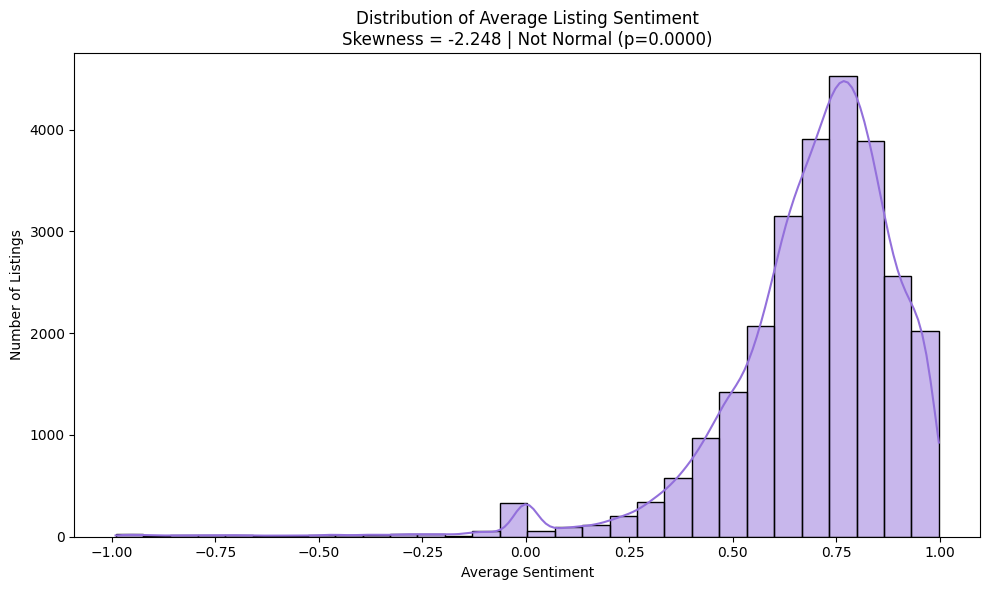

Skewness: -2.248


In [ ]:
#For each listing, we take the mean of all the review sentiment scores, then count the number of reviews per each listings for volume weighted sentiment
sentiment_per_listing = df_reviews.groupby("listing_id").agg(
    avg_sentiment=("sentiment_score_compound", "mean"),
    review_count=("sentiment_score_compound", "count")).reset_index()

display(sentiment_per_listing.head())

#Show the distribution of average sentiment scores
#Calculate skewness
skewness = skew(sentiment_per_listing["avg_sentiment"])

#Shapiro-Wilk normality test
stat, p_value = shapiro(
    sentiment_per_listing["avg_sentiment"].sample(
        min(5000, len(sentiment_per_listing)),
        random_state=1))

#Results (Normal Distribution if P>0.05)
normality = "Approximately Normal" if p_value > 0.05 else "Not Normal"

plt.figure(figsize=(10, 6))

sns.histplot(
    sentiment_per_listing["avg_sentiment"],
    bins=30,
    color="mediumpurple",
    kde=True)

plt.title(f"Distribution of Average Listing Sentiment\n"
    f"Skewness = {skewness:.3f} | {normality} (p={p_value:.4f})")

plt.xlabel("Average Sentiment")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()
print(f"Skewness: {skewness:.3f}")

# **12. Get Overall Mean of All Sentiment Scores**

In [ ]:
#Calculate mean sentiment score for all listings (range from -1 to 1)
overall_mean_sentiment_score = df_reviews["sentiment_score_compound"].mean()
print(f"""The overall mean sentiment score is {overall_mean_sentiment_score}""")

#Set up the next step, get the median to use as a minimum review count thershold for weighted adjustments
display(sentiment_per_listing["review_count"].describe())

The overall mean sentiment score is 0.7054250534273373


,review_count
count,26520.000000
mean,45.081033
std,76.516438
min,1.000000
25%,4.000000
50%,16.000000
75%,53.000000
max,2072.000000


In [ ]:
#Apply volume based weighting, shrinking the listings with few reviews towards the overall mean sentiment score
#Choose minimum review threshold, set to the median count of reviews of 16
m = 16

sentiment_per_listing["weighted_sentiment"] = ((sentiment_per_listing["review_count"] * sentiment_per_listing["avg_sentiment"] + m * overall_mean_sentiment_score)
    / (sentiment_per_listing["review_count"] + m))

display(sentiment_per_listing[["listing_id", "avg_sentiment", "weighted_sentiment", "review_count"]].head())

,listing_id,avg_sentiment,weighted_sentiment,review_count
0,1419,0.927567,0.766009,6
1,8077,0.904826,0.887392,167
2,26654,0.802238,0.776844,45
3,27423,0.910706,0.840823,31
4,29059,0.691630,0.692059,499


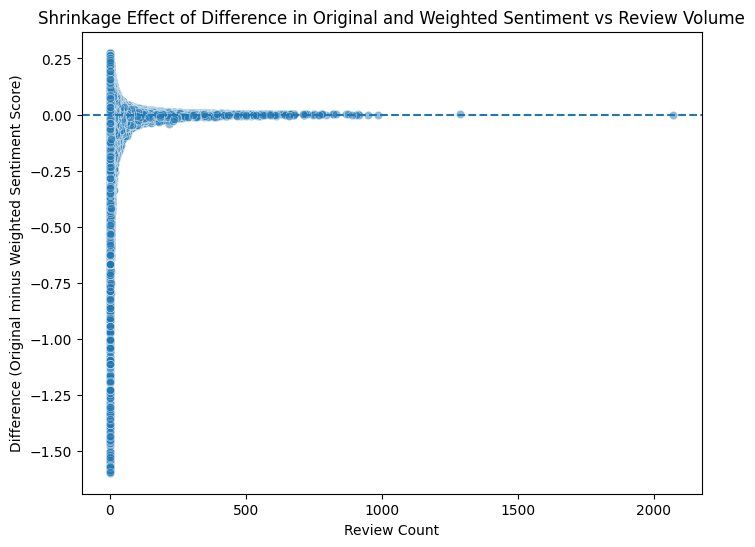

In [ ]:
#Show the shrinkage effect after weighing, showing the difference in average sentiment per listing vs weighted sentiment after review count weights are applied
#Left side (low number of reviews) have a big difference, being pulled towards the overall mean
#Right side (high number of reviews) have near zero difference
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sentiment_per_listing,
    x="review_count",
    y=(sentiment_per_listing["avg_sentiment"] - sentiment_per_listing["weighted_sentiment"]),
    alpha=0.5)

plt.axhline(0, linestyle="--")
plt.title("Shrinkage Effect of Difference in Original and Weighted Sentiment vs Review Volume")
plt.xlabel("Review Count")
plt.ylabel("Difference (Original minus Weighted Sentiment Score)")
plt.show()

# **13. Join Sentiment Scores with Listings Data**

In [ ]:
#Join the reviews sentiment scores with the preprocessed listings dataset on unique listing id
merged_with_reviews = pd.merge(sentiment_per_listing, df_listings, on="listing_id", how="inner")

#Check merge success
print(f"""The unique weighted sentiment scores are now: {sentiment_per_listing["weighted_sentiment"].unique()}""")
display(merged_with_reviews.head())
display(merged_with_reviews.shape)

print(f"The total number of rows of average weighted sentiments per listing is "f"{len(sentiment_per_listing)}")

#Check the 1 non-matching listing ID row that was removed
missing_ids = set(sentiment_per_listing["listing_id"]) - set(df_listings["listing_id"])
print(f"""The missing IDs that received no match are a count of {len(missing_ids)}, and the missing ID is {missing_ids}""")

#Drop listing_id, due to low predictive power
df_listings.drop(columns=["listing_id"], inplace=True, errors="ignore")
merged_with_reviews.drop(columns=["listing_id"], inplace=True, errors="ignore")

The unique weighted sentiment scores are now: [0.76600913 0.88739181 0.77684428 ... 0.72482227 0.72009417 0.70309417]


,listing_id,avg_sentiment,review_count,weighted_sentiment,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,neighbourhood_cleansed,...,reviews_per_month,city_code,host_year,years_as_host,first_review_year,years_since_first_review,last_review_year,years_since_last_review,bathrooms_text_to_numeric,log price
0,1419,0.927567,6,0.766009,NaN,0%,0%,0,1.0,Little Portugal,...,0,1,2008.0,18.0,2015.0,11.0,2017.0,9.0,3.0,4.820282
1,8077,0.904826,167,0.887392,NaN,0%,0%,0,2.0,Waterfront Communities-The Island,...,0,1,2009.0,17.0,2009.0,17.0,2013.0,13.0,1.5,4.820282
2,26654,0.802238,45,0.776844,within a few hours,0.91,0.33,1,3.0,Waterfront Communities-The Island,...,0,1,2010.0,16.0,2011.0,15.0,2025.0,1.0,1.0,4.897840
3,27423,0.910706,31,0.840823,NaN,0%,0%,0,1.0,South Riverdale,...,0,1,2010.0,16.0,2010.0,16.0,2025.0,1.0,1.0,4.330733
4,29059,0.691630,499,0.692059,within an hour,1.0,1.0,1,2.0,Ville-Marie,...,2,2,2010.0,16.0,2010.0,16.0,2025.0,1.0,1.0,4.905275


(26519, 29)

The total number of rows of average weighted sentiments per listing is 26520
The missing IDs that received no match are a count of 1, and the missing ID is {8629757}


# **14. Check Correlation of Review Sentiment with Log Adjusted Price**

In [ ]:
#Pearson correlation coefficient between weighted sentiment score and price (Airbnb listing price)
correlation = merged_with_reviews["weighted_sentiment"].corr(merged_with_reviews["log price"])
print(f"""The Pearson correlation shows a weak positive correlation
between the weighted sentiment score and log adjusted price of {correlation}""")

The Pearson correlation shows a weak positive correlation 
between the weighted sentiment score and log adjusted price of 0.22363727025236543


# **15. Create Random Forest Model to Predict Log Price on Listings Dataset vs Listings Dataset with Review Sentiment Scores**

In [ ]:
#Create the function to run random forest
def random_forest(df, target="log price", random_state=1):
    total_start = time.time()

    #Create target variable
    y = df[target]

    #Remove target and original price from predictors
    X = df.drop(columns=["log price", "price", "'log price'"],errors="ignore")

    #One hot encode categorical variables
    encoding_start = time.time()
    X = pd.get_dummies(X, drop_first=True)
    encoding_end = time.time()

    #Leakage checks for price and log price in test data
    print(f"\nShape after encoding: {X.shape}")
    print([col for col in X.columns if "price" in col.lower()])
    print("log price in X:", "log price" in X.columns)
    print("price in X:", "price" in X.columns)

    #Train-test split 20% and 80%
    split_start = time.time()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
    split_end = time.time()

    #Build model
    rf = RandomForestRegressor(n_estimators= 100, random_state=random_state, n_jobs=-1)

    #Train model
    train_start = time.time()
    rf.fit(X_train, y_train)
    train_end = time.time()

    #Predict
    predict_start = time.time()
    predictions = rf.predict(X_test)
    predict_end = time.time()
    total_end = time.time()

    #Feature importance dataframe
    feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_}).sort_values("Importance",ascending=False)

    #Timing report
    print(f"\nEncoding Time: {encoding_end - encoding_start:.2f} sec")
    print(f"Train/Test Split Time: {split_end - split_start:.2f} sec")
    print(f"Training Time: {train_end - train_start:.2f} sec")
    print(f"Prediction Time: {predict_end - predict_start:.2f} sec")
    print(f"Total Runtime: {total_end - total_start:.2f} sec")

    return ({"R²": r2_score(y_test, predictions),
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions))},
    feature_importance)

In [ ]:
#Check the cardinality of all categorical features, indicating the number of dummy variables created in the model
cardinality = pd.DataFrame({
    "Feature": merged_with_reviews.select_dtypes(
        include=["object", "category"]).columns, "Unique Values": [merged_with_reviews[col].nunique()
        for col in merged_with_reviews.select_dtypes(
            include=["object", "category"]
        ).columns]})

display(cardinality.sort_values(by="Unique Values",ascending=False))

,Feature,Unique Values
3,neighbourhood_cleansed,195
2,host_acceptance_rate,96
4,property_type,63
1,host_response_rate,58
0,host_response_time,4
5,room_type,4


# **16. Create XGBoost Model to Predict Log Price on Listings Dataset vs Listings Dataset with Review Sentiment Scores**

In [ ]:
#Create the function to run XGBoost
def xgboost_model(df, target="log price", random_state=1):
    total_start = time.time()

    #Create target variable
    y = df[target]

    #Remove target and original price from predictors
    X = df.drop(
        columns=["log price", "price", "'log price'"],
        errors="ignore")

    #One-hot encode categorical variables
    encoding_start = time.time()
    X = pd.get_dummies(X, drop_first=True)
    encoding_end = time.time()

    #Leakage checks
    print(f"\nShape after encoding: {X.shape}")
    print("log price in X:", "log price" in X.columns)
    print("price in X:", "price" in X.columns)

    #Train-test split
    split_start = time.time()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    split_end = time.time()

    #Build model
    xgb = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1)

    #Train model
    train_start = time.time()
    xgb.fit(X_train, y_train)
    train_end = time.time()

    #Predict
    predict_start = time.time()
    predictions = xgb.predict(X_test)
    predict_end = time.time()
    total_end = time.time()

    #Feature importance dataframe
    feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": xgb.feature_importances_}).sort_values(by="Importance",
        ascending=False)

    # Timing report
    print(f"\nEncoding Time: {encoding_end - encoding_start:.2f} sec")
    print(f"Train/Test Split Time: {split_end - split_start:.2f} sec")
    print(f"Training Time: {train_end - train_start:.2f} sec")
    print(f"Prediction Time: {predict_end - predict_start:.2f} sec")
    print(f"Total Runtime: {total_end - total_start:.2f} sec")

    return ({"R²": r2_score(y_test, predictions),
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": np.sqrt(mean_squared_error(y_test, predictions))},
        feature_importance,
        xgb,
        X_test)

# **17. Run Random Forest and XGBoost Models Predicting Log Price for Listings Dataset vs Listings Dataset with Review Sentiment Scores**

In [ ]:
#RANDOM FOREST
#Listings model
listings_metrics, listings_feature_importance = random_forest(df_listings)

#Reviews model
reviews_metrics, reviews_feature_importance = random_forest(merged_with_reviews)


Shape after encoding: (33748, 448)
[]
log price in X: False
price in X: False

Encoding Time: 0.06 sec
Train/Test Split Time: 0.04 sec
Training Time: 91.00 sec
Prediction Time: 0.27 sec
Total Runtime: 91.37 sec

Shape after encoding: (26519, 435)
[]
log price in X: False
price in X: False

Encoding Time: 0.04 sec
Train/Test Split Time: 0.03 sec
Training Time: 68.64 sec
Prediction Time: 0.19 sec
Total Runtime: 68.90 sec


In [ ]:
#XGBOOST
#Listings model
xgb_listings_metrics, xgb_listings_importance, xgb_listings_model, xgb_X_test_listings = (xgboost_model(df_listings))

#Reviews Model
xgb_reviews_metrics, xgb_reviews_importance, xgb_reviews_model, xgb_X_test_reviews = (xgboost_model(merged_with_reviews))


Shape after encoding: (33748, 448)
log price in X: False
price in X: False

Encoding Time: 0.05 sec
Train/Test Split Time: 0.04 sec
Training Time: 3.56 sec
Prediction Time: 0.10 sec
Total Runtime: 3.76 sec

Shape after encoding: (26519, 435)
log price in X: False
price in X: False

Encoding Time: 0.04 sec
Train/Test Split Time: 0.03 sec
Training Time: 4.67 sec
Prediction Time: 0.09 sec
Total Runtime: 4.83 sec


# **18. Show Performance Metrics for Random Forest and XGBoost Models**

In [ ]:
#Show Performance Results of Random Forest
results_df = pd.DataFrame([
    {"Dataset": "Listings Selected", **listings_metrics},
    {"Dataset": "Selected + Reviews", **reviews_metrics}])

display(results_df.sort_values("R²", ascending=False))

,Dataset,R²,MAE,RMSE
1,Selected + Reviews,0.673318,0.237928,0.361512
0,Listings Selected,0.653570,0.234853,0.369594


In [ ]:
#Show Performance Results of XGBoost
xgb_results_df = pd.DataFrame([
    {"Dataset": "Listings Selected", **xgb_listings_metrics},
    {"Dataset": "Selected + Reviews", **xgb_reviews_metrics}])

display(xgb_results_df.sort_values("R²", ascending=False))

,Dataset,R²,MAE,RMSE
1,Selected + Reviews,0.669501,0.249816,0.363617
0,Listings Selected,0.635727,0.256853,0.378992


# **19. Show Top 20 Features for Random Forest Model**

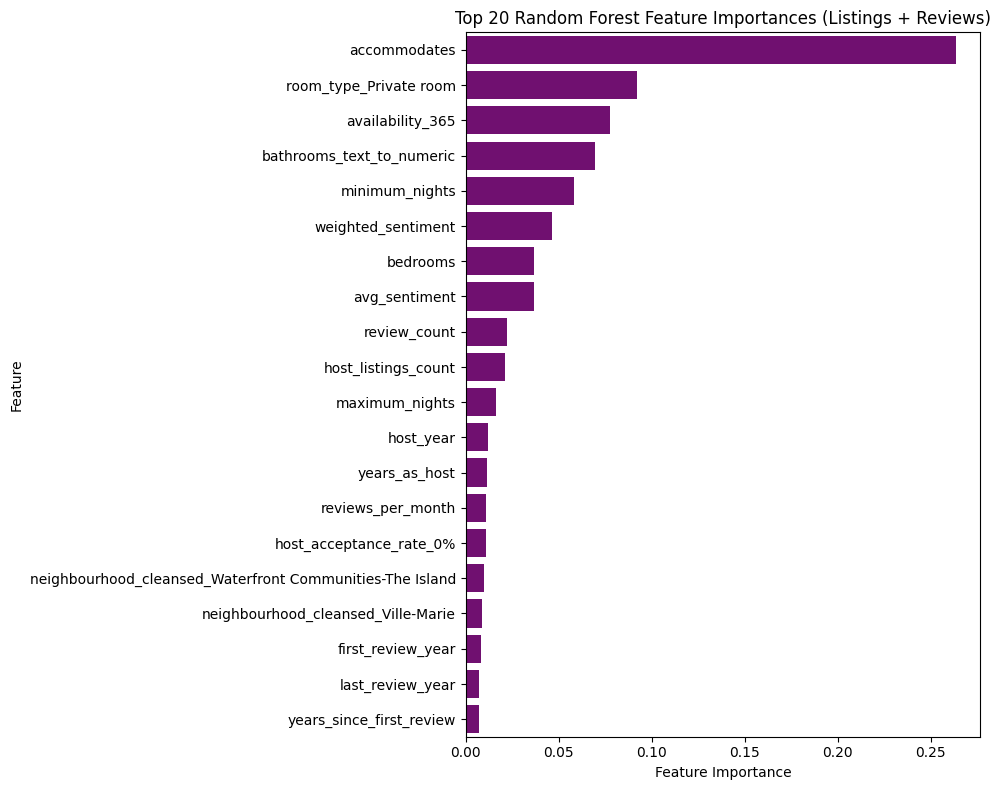

In [ ]:
#Random Forest Top 20 Features by Importance
top_features = reviews_feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(data=top_features,
    x="Importance",
    y="Feature",
    color="purple")

plt.title("Top 20 Random Forest Feature Importances (Listings + Reviews)")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# **18. Show SHAP Feature Importance Plot for XGBoost Model Only**

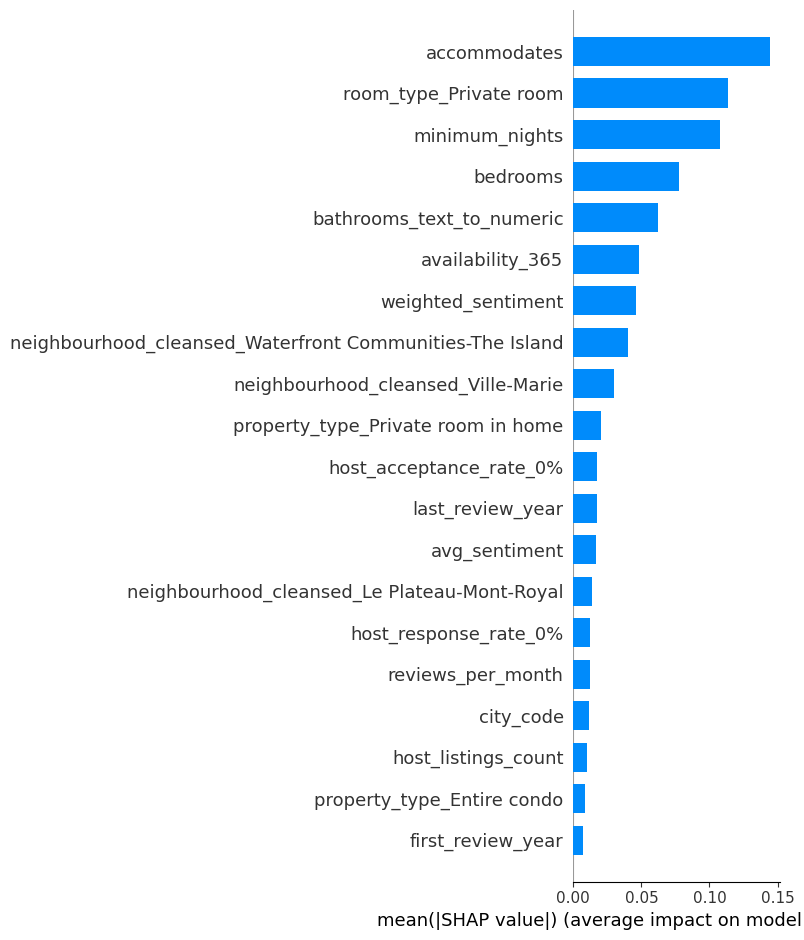

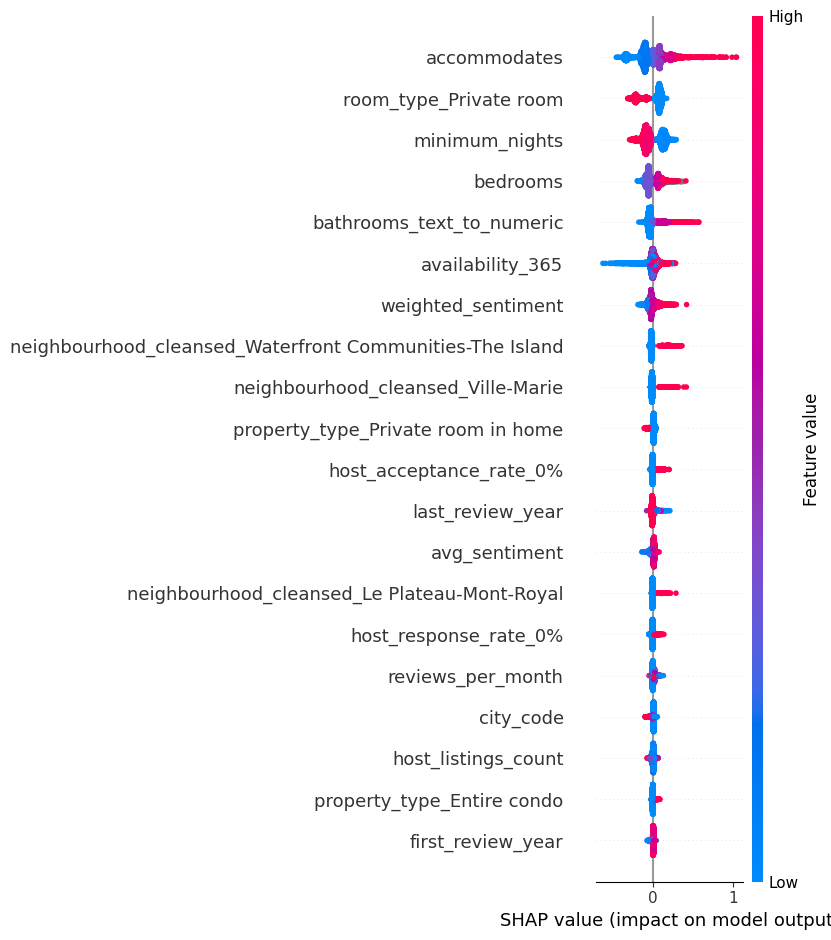

In [ ]:
#XGBoost SHAP Importance Plot
#Create SHAP explainer using XGBoost Model
explainer = shap.TreeExplainer(xgb_reviews_model)

#Calculate SHAP values
shap_values = explainer.shap_values(xgb_X_test_reviews)

#SHAP Feature Importance Plot
shap.summary_plot(shap_values, xgb_X_test_reviews, plot_type="bar")

#SHAP Bar Plot
shap.summary_plot(shap_values, xgb_X_test_reviews)